In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

EPOCHS = 6
BATCH_SIZE = 128

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Fashion-MNIST contains 28x28 grayscale clothing images.
# For an autoencoder, labels are not used during training.

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalise pixel values from 0-255 to 0-1.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Use a smaller subset so the tutorial runs quickly.
x_train_small = x_train[:10000]
x_val_small = x_test[:2000]
x_test_small = x_test[2000:3000]

# Flatten each 28x28 image into 784 pixel values.
x_train_flat = x_train_small.reshape((x_train_small.shape[0], 784))
x_val_flat = x_val_small.reshape((x_val_small.shape[0], 784))
x_test_flat = x_test_small.reshape((x_test_small.shape[0], 784))

print("Training data:", x_train_flat.shape)
print("Validation data:", x_val_flat.shape)
print("Test data:", x_test_flat.shape)
print("One image has 784 values because 28 x 28 =", 28 * 28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (10000, 784)
Validation data: (2000, 784)
Test data: (1000, 784)
One image has 784 values because 28 x 28 = 784


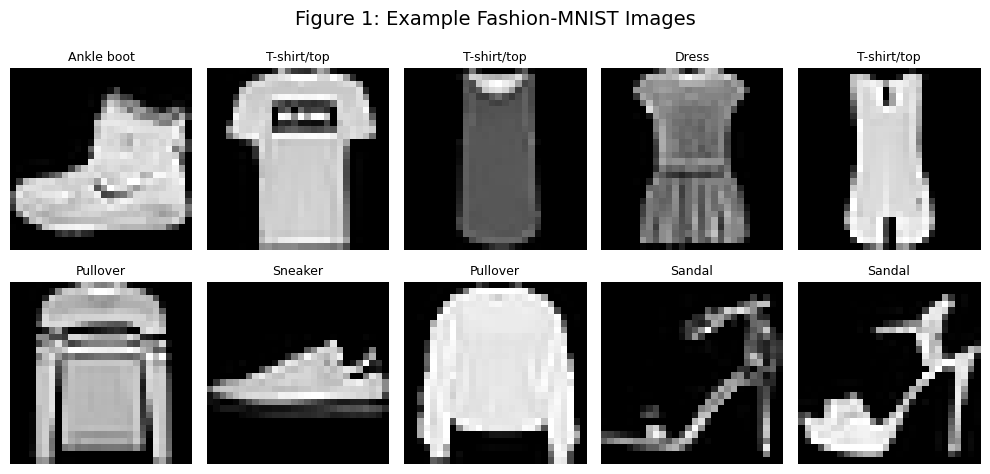

In [3]:
# This figure introduces the dataset.
# The autoencoder will learn to reconstruct these images, not classify them.

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")

plt.suptitle("Figure 1: Example Fashion-MNIST Images", fontsize=14)
plt.tight_layout()
plt.savefig("figures/figure_1_sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

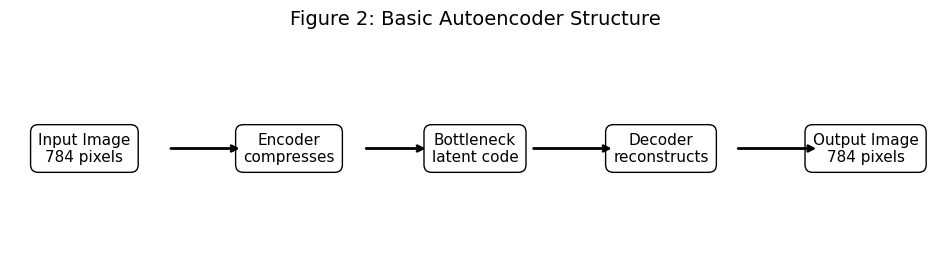

In [4]:
# This diagram explains the central idea:
# input image -> compressed bottleneck -> reconstructed image.

plt.figure(figsize=(12, 3))
plt.axis("off")

boxes = [
    ("Input Image\n784 pixels", 0.08),
    ("Encoder\ncompresses", 0.30),
    ("Bottleneck\nlatent code", 0.50),
    ("Decoder\nreconstructs", 0.70),
    ("Output Image\n784 pixels", 0.92)
]

for text, x in boxes:
    plt.text(
        x, 0.5, text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white")
    )

for x1, x2 in [(0.17, 0.25), (0.38, 0.45), (0.56, 0.65), (0.78, 0.87)]:
    plt.annotate(
        "",
        xy=(x2, 0.5),
        xytext=(x1, 0.5),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

plt.title("Figure 2: Basic Autoencoder Structure", fontsize=14)
plt.savefig("figures/figure_2_autoencoder_structure.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# The bottleneck is smaller than the input.
# This forces the model to keep only useful information for reconstruction.

def build_autoencoder(latent_dim=32):
    input_img = layers.Input(shape=(784,), name="input_image")

    encoded = layers.Dense(128, activation="relu", name="encoder_layer")(input_img)
    bottleneck = layers.Dense(latent_dim, activation="relu", name="bottleneck")(encoded)

    decoded = layers.Dense(128, activation="relu", name="decoder_layer")(bottleneck)
    output_img = layers.Dense(784, activation="sigmoid", name="reconstructed_image")(decoded)

    autoencoder = models.Model(input_img, output_img, name=f"autoencoder_latent_{latent_dim}")

    autoencoder.compile(
        optimizer="adam",
        loss="mse"
    )

    return autoencoder


main_autoencoder = build_autoencoder(latent_dim=32)
main_autoencoder.summary()

# Input and target are the same image.
# This is reconstruction learning.
history = main_autoencoder.fit(
    x_train_flat,
    x_train_flat,
    validation_data=(x_val_flat, x_val_flat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Model: "autoencoder_latent_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer (Dense)           │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_image (Dense)     │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0784 - val_loss: 0.0441
Epoch 2/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0353 - val_loss: 0.0291
Epoch 3/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0265 - val_loss: 0.0241
Epoch 4/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0234 - val_loss: 0.0222
Epoch 5/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0217 - val_loss: 0.0209
Epoch 6/6
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0206 - val_loss: 0.0200


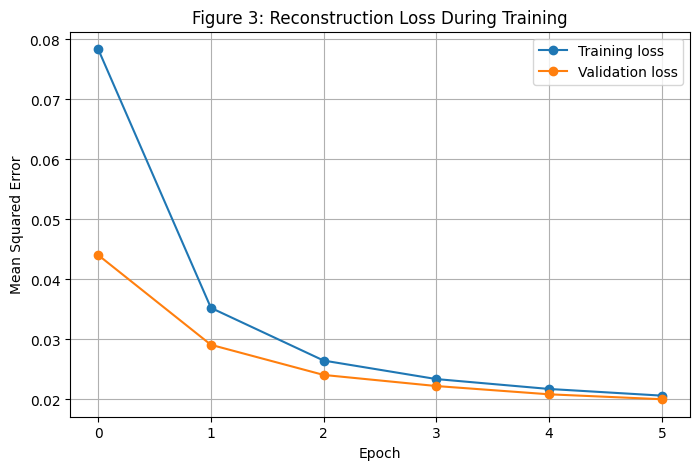

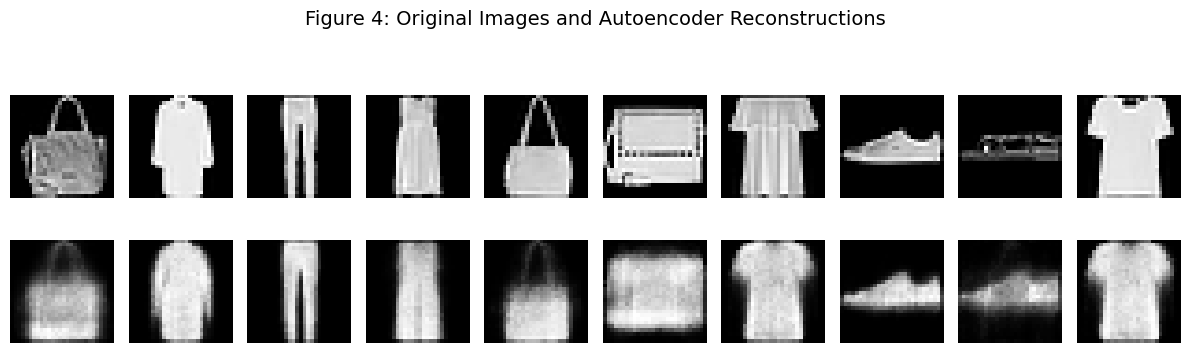

In [6]:
# Figure 3 shows whether reconstruction error decreases during training.

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation loss")
plt.title("Figure 3: Reconstruction Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.savefig("figures/figure_3_reconstruction_loss.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 4 compares original images with reconstructed images.

reconstructed = main_autoencoder.predict(x_test_flat[:10], verbose=0)

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original", fontsize=10)

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstructed", fontsize=10)

plt.suptitle("Figure 4: Original Images and Autoencoder Reconstructions", fontsize=14)
plt.tight_layout()
plt.savefig("figures/figure_4_original_vs_reconstructed.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# This is the main tutorial experiment.
# A smaller bottleneck gives stronger compression.
# A larger bottleneck usually preserves more detail.

latent_sizes = [8, 32, 64]
models_by_latent = {}
reconstructions_by_latent = {}
mse_by_latent = []

for latent_dim in latent_sizes:
    print("\nTraining autoencoder with bottleneck size:", latent_dim)

    model = build_autoencoder(latent_dim=latent_dim)

    model.fit(
        x_train_flat,
        x_train_flat,
        validation_data=(x_val_flat, x_val_flat),
        epochs=4,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1
    )

    recon = model.predict(x_test_flat[:8], verbose=0)
    full_recon = model.predict(x_test_flat, verbose=0)

    models_by_latent[latent_dim] = model
    reconstructions_by_latent[latent_dim] = recon

    mse = np.mean((x_test_flat - full_recon) ** 2)
    mse_by_latent.append(mse)

    print("Mean squared reconstruction error:", round(mse, 5))


Training autoencoder with bottleneck size: 8
Epoch 1/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0893 - val_loss: 0.0623
Epoch 2/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0544 - val_loss: 0.0427
Epoch 3/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0375 - val_loss: 0.0311
Epoch 4/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0292 - val_loss: 0.0272
Mean squared reconstruction error: 0.02694

Training autoencoder with bottleneck size: 32
Epoch 1/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0788 - val_loss: 0.0440
Epoch 2/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0352 - val_loss: 0.0284
Epoch 3/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0265 - val_loss: 0.0254
Epoch 4/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0232 - val_loss: 0.0217
Mean squared reconstruction error: 0.02161

Training autoencoder with bottleneck size: 64
Epoch 1/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0765 - val_loss: 0.0417
Epoch 2/4
79/79 ━━

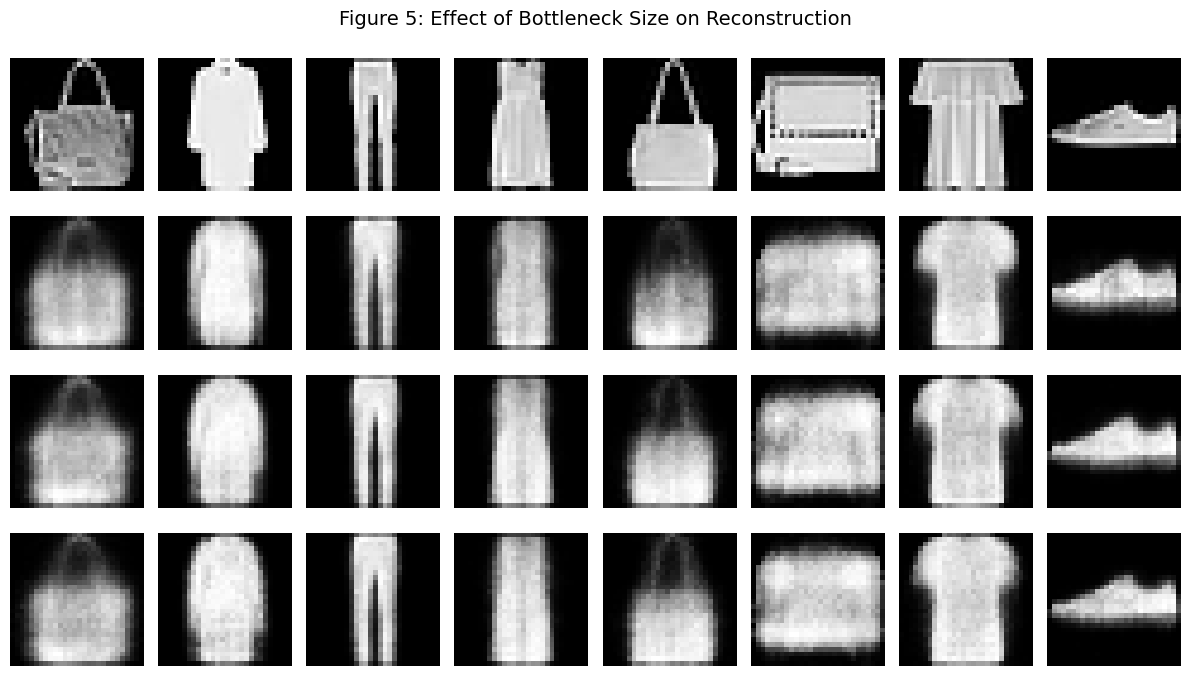

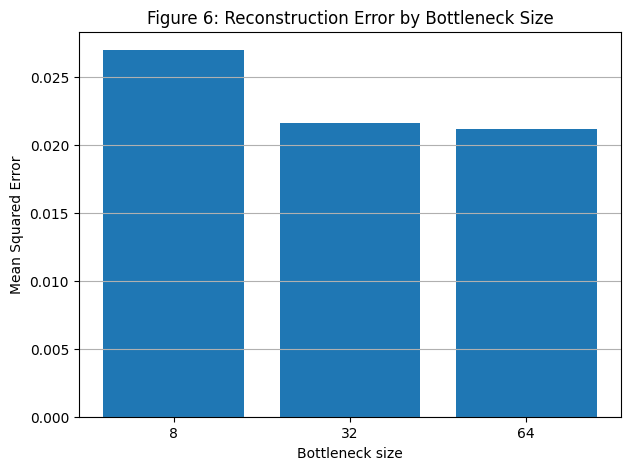


Final reconstruction errors:
Bottleneck size 8: MSE = 0.02694
Bottleneck size 32: MSE = 0.02161
Bottleneck size 64: MSE = 0.02116


In [8]:
# Figure 5 shows how bottleneck size affects reconstruction quality.

plt.figure(figsize=(12, 7))

for i in range(8):
    plt.subplot(4, 8, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original", fontsize=9)

for row, latent_dim in enumerate(latent_sizes):
    recon = reconstructions_by_latent[latent_dim]

    for i in range(8):
        plt.subplot(4, 8, (row + 1) * 8 + i + 1)
        plt.imshow(recon[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(f"Latent {latent_dim}", fontsize=9)

plt.suptitle("Figure 5: Effect of Bottleneck Size on Reconstruction", fontsize=14)
plt.tight_layout()
plt.savefig("figures/figure_5_bottleneck_size_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Figure 6 gives a numerical comparison of reconstruction error.

plt.figure(figsize=(7, 5))
plt.bar([str(size) for size in latent_sizes], mse_by_latent)
plt.title("Figure 6: Reconstruction Error by Bottleneck Size")
plt.xlabel("Bottleneck size")
plt.ylabel("Mean Squared Error")
plt.grid(axis="y")
plt.savefig("figures/figure_6_reconstruction_error_by_bottleneck.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nFinal reconstruction errors:")
for size, mse in zip(latent_sizes, mse_by_latent):
    print(f"Bottleneck size {size}: MSE = {mse:.5f}")